/var/folders/h3/gxsg9l7j7yb4ks48250kxs900000gn/T/ipykernel_29818/2939450105.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(symbol, start, end)
[*********************100%***********************]  1 of 1 completed

10630.599609375
10405.599609375


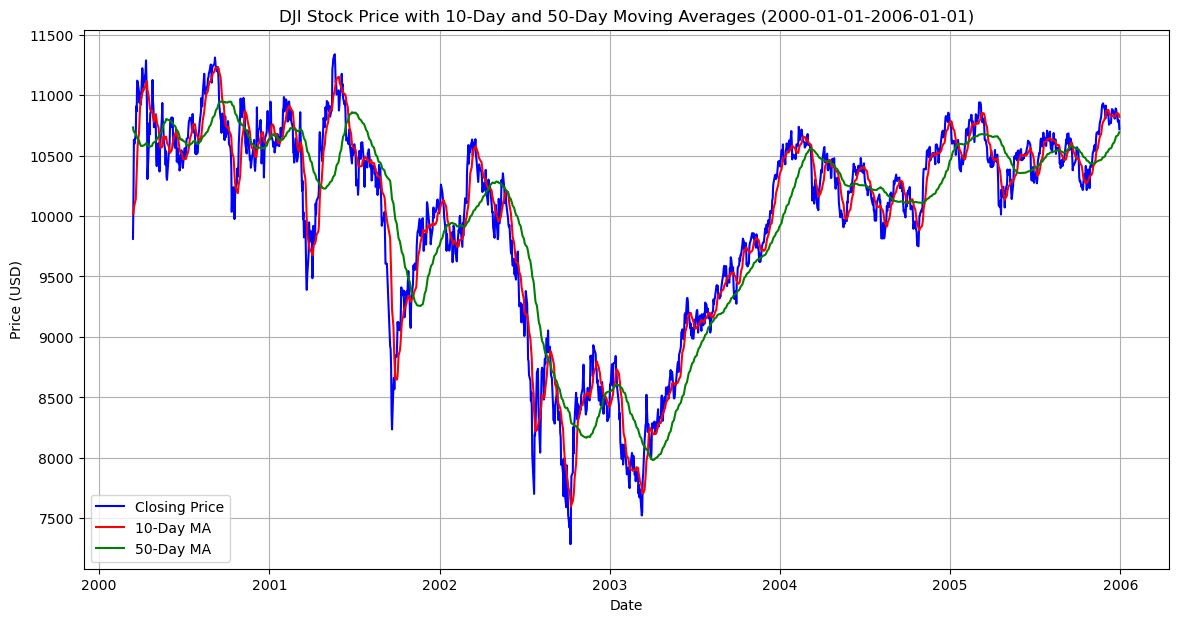

{'action': 'buy', 'price': 9811.240234375, 'index': Timestamp('2000-03-14 00:00:00')}
{'action': 'sell', 'price': 10680.2001953125, 'index': Timestamp('2000-03-20 00:00:00')}
{'action': 'buy', 'price': 10305.7998046875, 'index': Timestamp('2000-04-14 00:00:00')}
{'action': 'sell', 'price': 10906.099609375, 'index': Timestamp('2000-04-24 00:00:00')}
{'action': 'buy', 'price': 10480.099609375, 'index': Timestamp('2000-05-03 00:00:00')}
{'action': 'buy', 'price': 10412.5, 'index': Timestamp('2000-05-04 00:00:00')}
{'action': 'buy', 'price': 10577.900390625, 'index': Timestamp('2000-05-05 00:00:00')}
{'action': 'buy', 'price': 10603.599609375, 'index': Timestamp('2000-05-08 00:00:00')}
{'action': 'buy', 'price': 10536.7998046875, 'index': Timestamp('2000-05-09 00:00:00')}
{'action': 'buy', 'price': 10367.7998046875, 'index': Timestamp('2000-05-10 00:00:00')}
{'action': 'buy', 'price': 10546.0, 'index': Timestamp('2000-05-11 00:00:00')}
{'action': 'sell', 'price': 10807.7998046875, 'index':

In [56]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


start = "2000-01-01"
end = "2006-01-01"
symbol = "DJI"
close = f"Close_{symbol}"
raw_data = yf.download(symbol, start, end)

raw_data.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in raw_data.columns]

raw_data['MA10'] = raw_data[close].rolling(window=10).mean()
raw_data['MA50'] = raw_data[close].rolling(window=50).mean()

data = raw_data.dropna(subset=[close, 'MA50']).copy() #sets data as a copy of raw data and removes any rows where ma50 has no value

start_price = data.loc["2000-03-16", close]
print(start_price)
end_price = data.loc["2005-06-28", close]
print(end_price)


data['Signal'] = np.where((data[close] < data['MA50']) & (data[close] < data['MA10']), 'buy',
                                 np.where((data[close] > data['MA10']) & (data[close] > data['MA50']), 'sell', 'hold'))


data['dif'] = data['MA10'] - data['MA50']
streak_count = 0
consec_streaks = []
for i in range(len(data)):
    if data['MA10'].iloc[i] > data['MA50'].iloc[i]:
        if streak_count>=0:
            streak_count +=1
        else:
            streak_count = 1  # reset to start counting positive streak
    elif data['MA10'].iloc[i] < data['MA50'].iloc[i]:
        if streak_count <= 0:
            streak_count -= 1 #reset to start counting negative streak
        else:
            streak_count = -1
            
    consec_streaks.append(streak_count)
    
data['CD'] = consec_streaks

#print(data[['MA10', 'MA50', 'Signal', 'CD','dif']].head(10))
#print(data[['MA10', 'MA50', 'Signal', 'CD','dif']].tail(10))

plt.figure(figsize=(14,7))
plt.plot(data['Close_DJI'], label='Closing Price', color='blue')
plt.plot(data['MA10'], label='10-Day MA', color='red')
plt.plot(data['MA50'], label='50-Day MA', color='green')
plt.title(f'{symbol} Stock Price with 10-Day and 50-Day Moving Averages ({start}-{end})')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

def strategy():
    position = 0
    buys = 0
    buy_price = 0
    trades = []
    sell_prices = []
    buy_prices = []
    
    for idx, row in data.iterrows(): #common pandas iterates through rows 
        signal = row['Signal']
        price = row[close]
        
        if signal == 'buy':
            buy_price = price 
            buy_prices.append(buy_price)
            position += 1
            trades.append({'action': 'buy', 'price': buy_price, 'index': idx})
            buys += 1
            

        elif signal == 'sell' and position >= 1: #so only sells if actually own any          
            sell_price = price
            sell_prices.append(sell_price)
            position -= 1
            trades.append({'action': 'sell', 'price': sell_price, 'index': idx})
            
    leftover = 0       
    if position >= 1:
        if sell_prices:
            avg_sell_price = sum(sell_prices) / len(sell_prices)
        else:
            avg_sell_price = data[close_col].iloc[-1]
            
        leftover = avg_sell_price * position
        trades.append({'action': 'sell leftovers', 'price': avg_sell_price, 'quantity': leftover, 'index': idx})  
        
    spent = sum(buy_prices)
    generated = sum(sell_prices) + leftover
    profit = generated - spent
    DJI_perc_change = (end_price - start_price)/start_price
    return profit, trades, DJI_perc_change,buys

profit, trades, DJI_perc_change, buys = strategy() #if called w/o = it would print but varibales lost

for t in trades:
    print(t)
print("Total profit:", profit)
print(f"the percentage change of the DJI was {DJI_perc_change*100}%")
print(f"so if all bought at start and sold at end is profit = {buys*start_price*DJI_perc_change}")
print(f"you did {profit - buys*start_price*DJI_perc_change} better than random")